# FeedForward neural network: AlexNet

## Imports

In [375]:
from pathlib import Path
from matplotlib import pyplot
from matplotlib import gridspec
from PIL import Image
from torch import nn
from os import listdir
from os.path import isfile, join

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optimizer
import math
import torchvision
import sklearn
import pandas as pd

## Preparing the data

(499, 375)


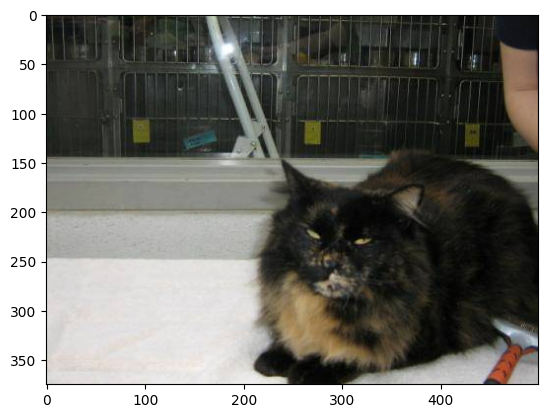

In [348]:
DATA_PATH = Path("../../data")
PATH = DATA_PATH / "cnd"

img = Image.open(PATH/"training_set/cats/cat.150.jpg")
print(img.size)

pyplot.imshow(img)
pyplot.show()

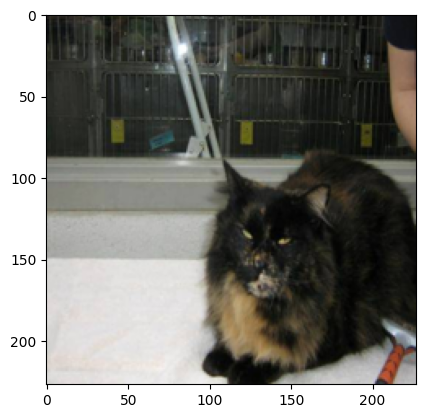

In [258]:
def scale_resize_image(image):
    resize_transform = torchvision.transforms.Resize((227, 227), interpolation=torchvision.transforms.InterpolationMode.BICUBIC)
    image = np.array(resize_transform.forward(image))
    return image

def get_valid_image(path):
    img = Image.open(path)
    val = scale_resize_image(img)
    val = np.moveaxis(val, -1, 0) # needed to move the channel to the first spot
    # val = np.expand_dims(val, 0)
    return val

val = scale_resize_image(img)
pyplot.imshow(val)
pyplot.show()

In [405]:
dataset_X = []
dataset_Y = []
for f in listdir(PATH/"training_set/cats"):
    if isfile(join(PATH/"training_set/cats", f)) and f[-4:] == ".jpg":
        dataset_X.append(torch.tensor(get_valid_image(PATH/"training_set/cats"/f)).to(torch.float32))
        dataset_Y.append(torch.tensor((1,0)).to(torch.float32))
for f in listdir(PATH/"training_set/dogs"):
    if isfile(join(PATH/"training_set/dogs", f)) and f[-4:] == ".jpg":
        dataset_X.append(torch.tensor(get_valid_image(PATH/"training_set/dogs"/f)).to(torch.float32))
        dataset_Y.append(torch.tensor((0,1)).to(torch.float32))

df = pd.DataFrame(data={"image":dataset_X, "label":dataset_Y})
df = df.sample(frac=1).reset_index(drop=True)

In [308]:
df.head()

,image,label
0,"[[[tensor(163.), tensor(163.), tensor(164.), t...","[tensor(0.), tensor(1.)]"
1,"[[[tensor(135.), tensor(161.), tensor(174.), t...","[tensor(1.), tensor(0.)]"
2,"[[[tensor(232.), tensor(232.), tensor(232.), t...","[tensor(0.), tensor(1.)]"
3,"[[[tensor(180.), tensor(180.), tensor(180.), t...","[tensor(0.), tensor(1.)]"
4,"[[[tensor(224.), tensor(212.), tensor(179.), t...","[tensor(0.), tensor(1.)]"


## Feedforward Neural Network

In [457]:
class AlexNet(nn.Module):
    def __init__(self):
        super(AlexNet, self).__init__()
        # Layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4)
        self.conv2 = nn.Conv2d(in_channels=96, out_channels=256, kernel_size=5, stride=1, padding=2)
        self.conv3 = nn.Conv2d(in_channels=256, out_channels=384, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(in_channels=384, out_channels=384, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(9216, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, 2)

        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.maxpool2 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.maxpool3 = nn.MaxPool2d(kernel_size=3, stride=2)

        self.dropout = nn.Dropout(p=0.5)
        
    # x represents our data
    def forward(self, x):
        # Layer 1
        x = nn.functional.relu(self.conv1(x))
        x = self.maxpool1(x)
        # Layer 2
        x = nn.functional.relu(self.conv2(x))
        x = self.maxpool2(x)
        # Layer 3
        x = nn.functional.relu(self.conv3(x))
        x = nn.functional.relu(self.conv4(x))
        x = nn.functional.relu(self.conv5(x))
        x = self.maxpool3(x)
        x = torch.flatten(x)
        # Layer 4
        x = self.dropout(nn.functional.relu(self.fc1(x)))
        x = self.dropout(nn.functional.relu(self.fc2(x)))
        x = self.fc3(x)

        # Apply softmax to x
        output = x

        return output

In [439]:
class CustomNet(nn.Module):
    def __init__(self):
        super(CustomNet, self).__init__()
        # Layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=12, kernel_size=6, padding=1, stride=2)
        self.conv2 = nn.Conv2d(in_channels=12, out_channels=24, kernel_size=6, padding=1, stride=5)

        self.avgpool1 = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)
        self.avgpool2 = nn.AvgPool2d(kernel_size=4, stride=3, padding=1)

        self.fc1 = nn.Linear(in_features=1176, out_features=512)
        self.fc2 = nn.Linear(in_features=512, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=2)
        
    # x represents our data
    def forward(self, x):
        # Layer 1
        x = nn.functional.relu(self.conv1(x)) # 227x227x3 -> 112x112x12
        x = self.avgpool1(x) #112x112x12 -> 112x112x12

        # Layer 2
        x = nn.functional.relu(self.conv2(x)) # 112x112x12 -> 22x22x24
        x = self.avgpool2(x)
        x = torch.flatten(x)

        # Layer 3
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        x = self.fc3(x)

        return x

## Training the model

In [446]:
custom_net = CustomNet()
criterion = nn.CrossEntropyLoss()
opt = optimizer.SGD(custom_net.parameters(),lr=0.001)
# opt = optimizer.Adam(custom_net.parameters(),lr=0.0001)

# X_train, X_valid, Y_train, Y_valid = sklearn.model_selection.train_test_split(df.image, df.label, test_size=0.2, random_state=10, shuffle=True)
# X_train, X_valid, Y_train, Y_valid = sklearn.model_selection.train_test_split(df.image, df.label, test_size=0.2, random_state=10, shuffle=True)
samples = df.sample(int(0.8*len(df)))
validation = pd.concat([df,samples]).drop_duplicates(keep=False)

validation_loss = []
training_loss = []
for epoch in range(20):
    t_loss = 0
    running_loss = 0
    i = 0
    for _, row in samples.iterrows():
        opt.zero_grad()

        outputs = custom_net(row.image)
        loss = criterion(outputs, row.label)
        loss.backward()
        opt.step()

        running_loss += loss.item()
        t_loss += loss.item()
        # if i == 10:
        #     break
        if i % 500 == 499:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 500:.3f}')
            print(torch.softmax(outputs, 0), row.label)
            running_loss = 0.0
        i += 1
    training_loss.append(t_loss/i)
    j = 0
    with torch.no_grad():
        val = 0
        for _, row in validation.iterrows():
            outputs = custom_net(row.image)
            loss = criterion(outputs, row.label)
            val += loss.item()
            j += 1
        validation_loss.append(val/j)
        
        

[1,   500] loss: 0.717
tensor([0.5034, 0.4966], grad_fn=<SoftmaxBackward0>) tensor([1., 0.])
[1,  1000] loss: 0.693
tensor([0.4778, 0.5222], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  1500] loss: 0.693
tensor([0.4179, 0.5821], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  2000] loss: 0.697
tensor([0.4863, 0.5137], grad_fn=<SoftmaxBackward0>) tensor([1., 0.])
[1,  2500] loss: 0.690
tensor([0.4795, 0.5205], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  3000] loss: 0.689
tensor([0.4886, 0.5114], grad_fn=<SoftmaxBackward0>) tensor([1., 0.])
[1,  3500] loss: 0.688
tensor([0.4347, 0.5653], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  4000] loss: 0.682
tensor([0.4841, 0.5159], grad_fn=<SoftmaxBackward0>) tensor([1., 0.])
[1,  4500] loss: 0.681
tensor([0.5126, 0.4874], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  5000] loss: 0.681
tensor([0.4082, 0.5918], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  5500] loss: 0.691
tensor([0.4841, 0.5159], grad_fn=<SoftmaxBackwa

In [459]:
net = AlexNet()
# net = CustomNet()
criterion = nn.CrossEntropyLoss()
# opt = optimizer.SGD(net.parameters(),lr=0.001)
opt = optimizer.SGD(net.parameters(),lr=0.001, momentum=0.1)

# X_train, X_valid, Y_train, Y_valid = sklearn.model_selection.train_test_split(df.image, df.label, test_size=0.2, random_state=10, shuffle=True)
# X_train, X_valid, Y_train, Y_valid = sklearn.model_selection.train_test_split(dataset_X, dataset_Y, test_size=0.2, random_state=10, shuffle=True)
samples = df.sample(int(0.8*len(df)))
validation = pd.concat([df,samples]).drop_duplicates(keep=False)

validation_loss_alex = []
training_loss_alex = []
for epoch in range(10):
    t_loss = 0
    running_loss = 0
    i = 0
    for _, row in samples.iterrows():
        opt.zero_grad()

        outputs = net(row.image)
        loss = criterion(outputs, row.label)
        loss.backward()
        opt.step()
        # print(outputs, Y_train[i])

        # print statistics
        # with torch.no_grad():
        #     outputs = AlexNet(row)
        #     loss = criterion(outputs, Y_train[i])
        running_loss += loss.item()
        t_loss += loss.item()
        # if i == 10:
        #     break
        if i % 500 == 499:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 500:.3f}')
            print(torch.softmax(outputs, 0), row.label)
            running_loss = 0.0
        i+=1
    training_loss_alex.append(t_loss/i)
    j=0
    with torch.no_grad():
        val = 0
        for _, row in validation.iterrows():
            outputs = net(row.image)
            loss = criterion(outputs, row.label)
            val += loss.item()
            j+=1
        validation_loss_alex.append(val/j)
        

[1,   500] loss: 0.725
tensor([0.4713, 0.5287], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  1000] loss: 0.698
tensor([0.5394, 0.4606], grad_fn=<SoftmaxBackward0>) tensor([1., 0.])
[1,  1500] loss: 0.692
tensor([0.4688, 0.5312], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  2000] loss: 0.697
tensor([0.4724, 0.5276], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  2500] loss: 0.694
tensor([0.5294, 0.4706], grad_fn=<SoftmaxBackward0>) tensor([1., 0.])
[1,  3000] loss: 0.693
tensor([0.4761, 0.5239], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  3500] loss: 0.691
tensor([0.4139, 0.5861], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  4000] loss: 0.689
tensor([0.5248, 0.4752], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  4500] loss: 0.685
tensor([0.4771, 0.5229], grad_fn=<SoftmaxBackward0>) tensor([1., 0.])
[1,  5000] loss: 0.685
tensor([0.4801, 0.5199], grad_fn=<SoftmaxBackward0>) tensor([0., 1.])
[1,  5500] loss: 0.683
tensor([0.4420, 0.5580], grad_fn=<SoftmaxBackwa

KeyboardInterrupt: 

## Analysis of models

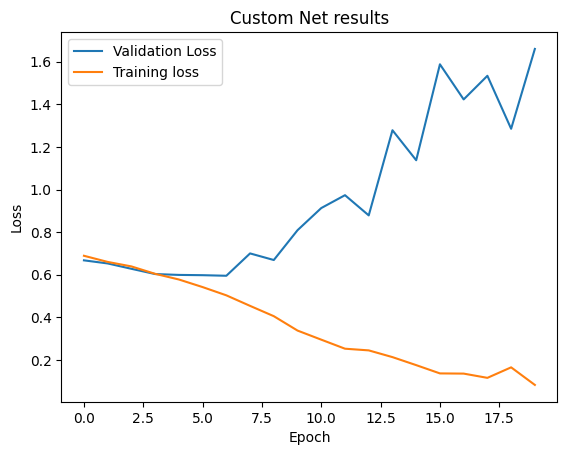

In [447]:
pyplot.plot(validation_loss, label="Validation Loss")
pyplot.plot(training_loss, label="Training loss")
pyplot.ylabel("Loss")
pyplot.xlabel("Epoch")
pyplot.title("Custom Net results")
pyplot.legend()

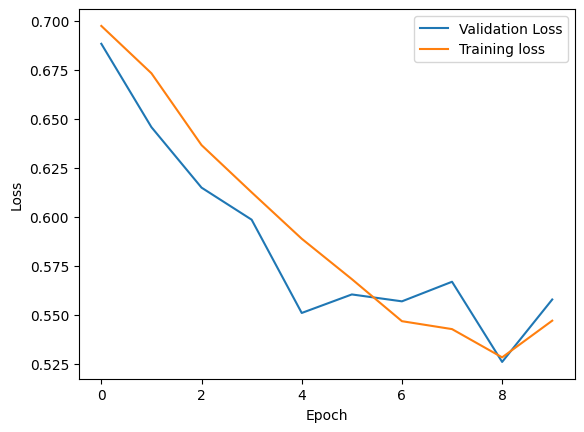

In [341]:
pyplot.plot(validation_loss_alex, label="Validation Loss")
pyplot.plot(training_loss_alex, label="Training loss")
pyplot.ylabel("Loss")
pyplot.xlabel("Epoch")
pyplot.title("AlexNet Results")
pyplot.legend()

In [345]:
save_path = './AlexNET.pth'
torch.save(net.state_dict(), PATH)

In [390]:
model_path = './AlexNET.pth'
new_net = AlexNet()
new_net.load_state_dict(torch.load(model_path, weights_only=True))

<All keys matched successfully>

In [359]:
X_test = []
Y_test = []
path_test = []
for f in listdir(PATH/"test_set/cats"):
    if isfile(join(PATH/"test_set/cats", f)) and f[-4:] == ".jpg":
        X_test.append(torch.tensor(get_valid_image(PATH/"test_set/cats"/f)).to(torch.float32))
        Y_test.append(torch.tensor((1,0)).to(torch.float32))
        path_test.append(PATH/"test_set/cats"/f)
for f in listdir(PATH/"test_set/dogs"):
    if isfile(join(PATH/"test_set/dogs", f)) and f[-4:] == ".jpg":
        X_test.append(torch.tensor(get_valid_image(PATH/"test_set/dogs"/f)).to(torch.float32))
        Y_test.append(torch.tensor((0,1)).to(torch.float32))
        path_test.append(PATH/"test_set/dogs"/f)

df_test = pd.DataFrame(data={"image":X_test, "label":Y_test, "path":path_test})
df_test = df_test.sample(frac=1).reset_index(drop=True)

['AlexNet: cat\nCustomNet: cat', 'AlexNet: dog\nCustomNet: cat', 'AlexNet: cat\nCustomNet: cat', 'AlexNet: dog\nCustomNet: dog', 'AlexNet: cat\nCustomNet: cat', 'AlexNet: dog\nCustomNet: cat', 'AlexNet: dog\nCustomNet: dog', 'AlexNet: cat\nCustomNet: cat', 'AlexNet: cat\nCustomNet: dog', 'AlexNet: dog\nCustomNet: cat', 'AlexNet: cat\nCustomNet: cat', 'AlexNet: cat\nCustomNet: dog', 'AlexNet: cat\nCustomNet: cat', 'AlexNet: dog\nCustomNet: dog', 'AlexNet: cat\nCustomNet: cat', 'AlexNet: cat\nCustomNet: cat', 'AlexNet: cat\nCustomNet: cat', 'AlexNet: cat\nCustomNet: dog', 'AlexNet: dog\nCustomNet: dog', 'AlexNet: dog\nCustomNet: cat']


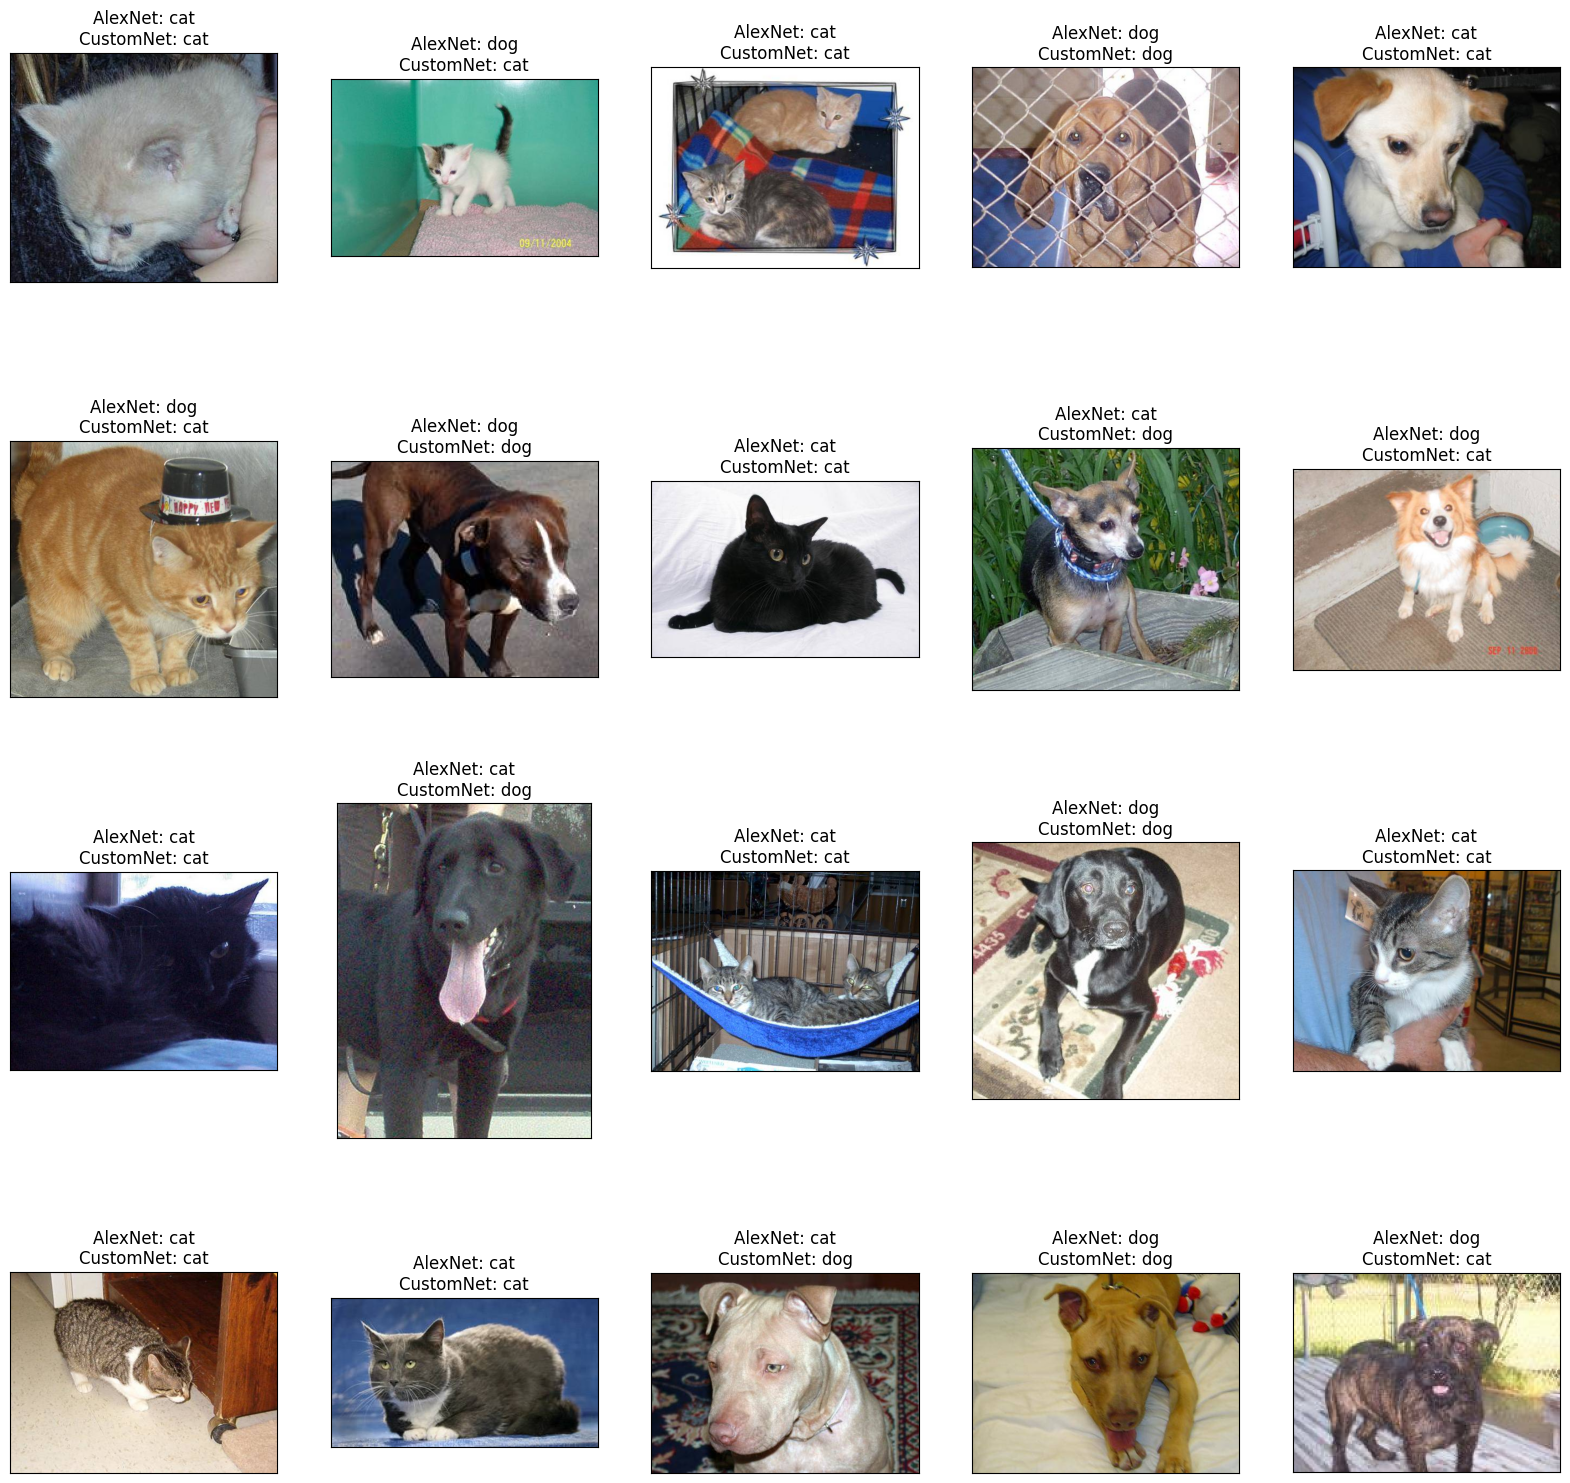

In [454]:
samples = df_test.sample(20)

x = []
title = []
for index, sample in samples.iterrows():
    x.append(sample.path)
    title.append("AlexNet: dog") if torch.argmax(new_net(sample.image)) else title.append("AlexNet: cat")
    title[-1] = f"{title[-1]}\nCustomNet: dog" if torch.argmax(custom_net(sample.image)) else f"{title[-1]}\nCustomNet: cat"
    
grid_size_x = math.floor((len(x))**(1/2))
grid_size_y = math.ceil((len(x))/grid_size_x)  
gs = gridspec.GridSpec(grid_size_x, grid_size_y)   
# gs.update(bottom=0.1)
# gs.update(top=0.55)
fig = pyplot.figure(constrained_layout = True)
fig.set_figwidth(20)
fig.set_figheight(20)
# Process image
for i, im in enumerate(x):
    ax = fig.add_subplot(gs[(i)//grid_size_y, (i)%grid_size_y])
    ax.imshow(Image.open(im))
    ax.set_title(title[i])
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)



pyplot.show()

In [342]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for i, data in enumerate(X_valid):
        # calculate outputs by running images through the network
        outputs = net(data)
        # the class with the highest energy is what we choose as prediction
        predicted = torch.argmax(outputs)
        total += 1
        correct += 1 if predicted == torch.argmax(Y_valid[i]) else 0
print(f"Accuracy is {correct/total}")

Accuracy is 0.7389131792629606


In [344]:
with torch.no_grad():
    outputs = []
    for i in range(10):
        outputs.append(net(X_valid[i]))
print(outputs)
print(Y_valid[:10])
        

[tensor([4.1903e-04, 9.9958e-01]), tensor([0.2266, 0.7734]), tensor([0.9498, 0.0502]), tensor([1.0000e+00, 1.4818e-07]), tensor([0.9910, 0.0090]), tensor([1.0000e+00, 1.5974e-06]), tensor([5.1005e-04, 9.9949e-01]), tensor([0.9964, 0.0036]), tensor([0.4613, 0.5387]), tensor([2.9912e-08, 1.0000e+00])]
[tensor([0., 1.]), tensor([0., 1.]), tensor([0., 1.]), tensor([1., 0.]), tensor([1., 0.]), tensor([1., 0.]), tensor([0., 1.]), tensor([1., 0.]), tensor([1., 0.]), tensor([0., 1.])]
